In [42]:
import pandas as pd
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifierg
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score , recall_score ,precision_score , confusion_matrix ,f1_score,ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline
from sklearn.model_selection import  cross_val_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import RandomOverSampler


In [43]:
data = pd.read_csv("../data/Parkinsson disease.csv")

#loading the data from file csv in the folder by pandas

In [44]:
print(data.shape)
print(data.head())

#showing data shape  and printing first 5 rows of the dataframe

(195, 24)
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \
0  

In [45]:
print(data.info())

#Data Exploration

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [46]:
print(data.describe())



       MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
count   195.000000    195.000000    195.000000      195.000000   
mean    154.228641    197.104918    116.324631        0.006220   
std      41.390065     91.491548     43.521413        0.004848   
min      88.333000    102.145000     65.476000        0.001680   
25%     117.572000    134.862500     84.291000        0.003460   
50%     148.790000    175.829000    104.315000        0.004940   
75%     182.769000    224.205500    140.018500        0.007365   
max     260.105000    592.030000    239.170000        0.033160   

       MDVP:Jitter(Abs)    MDVP:RAP    MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
count        195.000000  195.000000  195.000000  195.000000    195.000000   
mean           0.000044    0.003306    0.003446    0.009920      0.029709   
std            0.000035    0.002968    0.002759    0.008903      0.018857   
min            0.000007    0.000680    0.000920    0.002040      0.009540   
25%            0.000

In [47]:
data = data.drop(["name"] , axis=1)

# Remove the 'name' column before creating the correlation heatmap

In [48]:
data.isnull().sum()

#checking for  missing values in dataframe

MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [49]:
print(data["status"].value_counts())

# Check the class distribution in the 'status' column

status
1    147
0     48
Name: count, dtype: int64


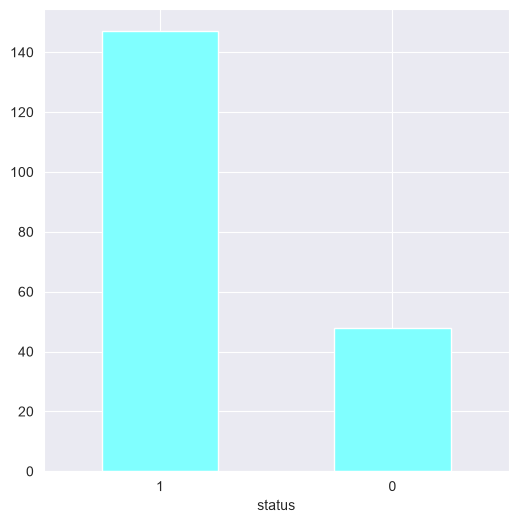

In [50]:
data["status"].value_counts().plot(
    kind ="bar" ,
    figsize=(6,6) ,
    rot = 360 ,
    color = [(0.5,1,1)]
)
plt.savefig("../images/status histogram.png" , dpi=300, bbox_inches="tight")

# Plot a histogram of the target variable (status)

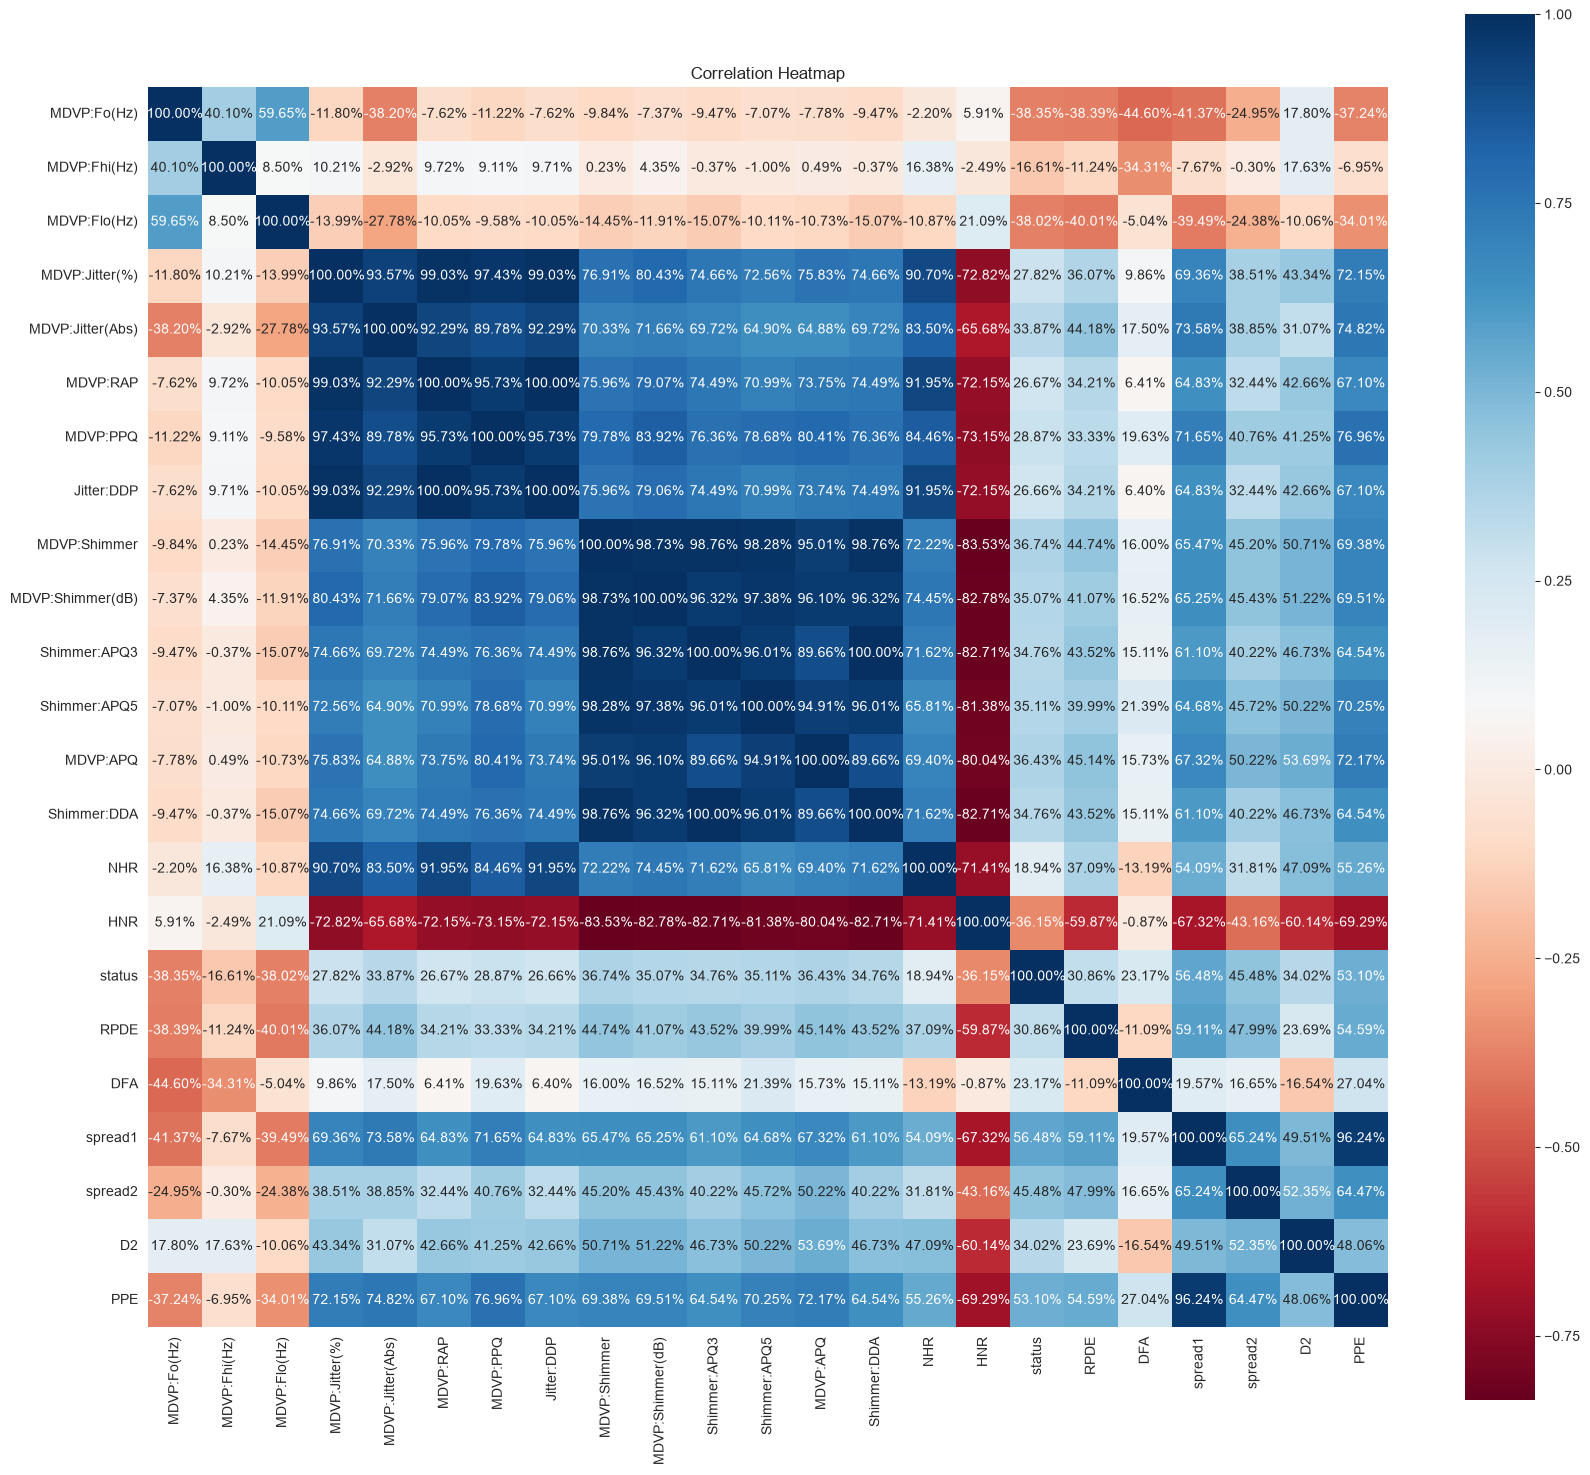

In [51]:
plt.figure(figsize=(20,18))
corr = data.corr()
sns.heatmap(corr ,
          cmap="RdBu" ,
          annot=True  ,
          square=True,
          fmt=".2%"  )
plt.title("Correlation Heatmap")
plt.savefig("../images/heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Calculate the correlation matrix and display it as a heatmap

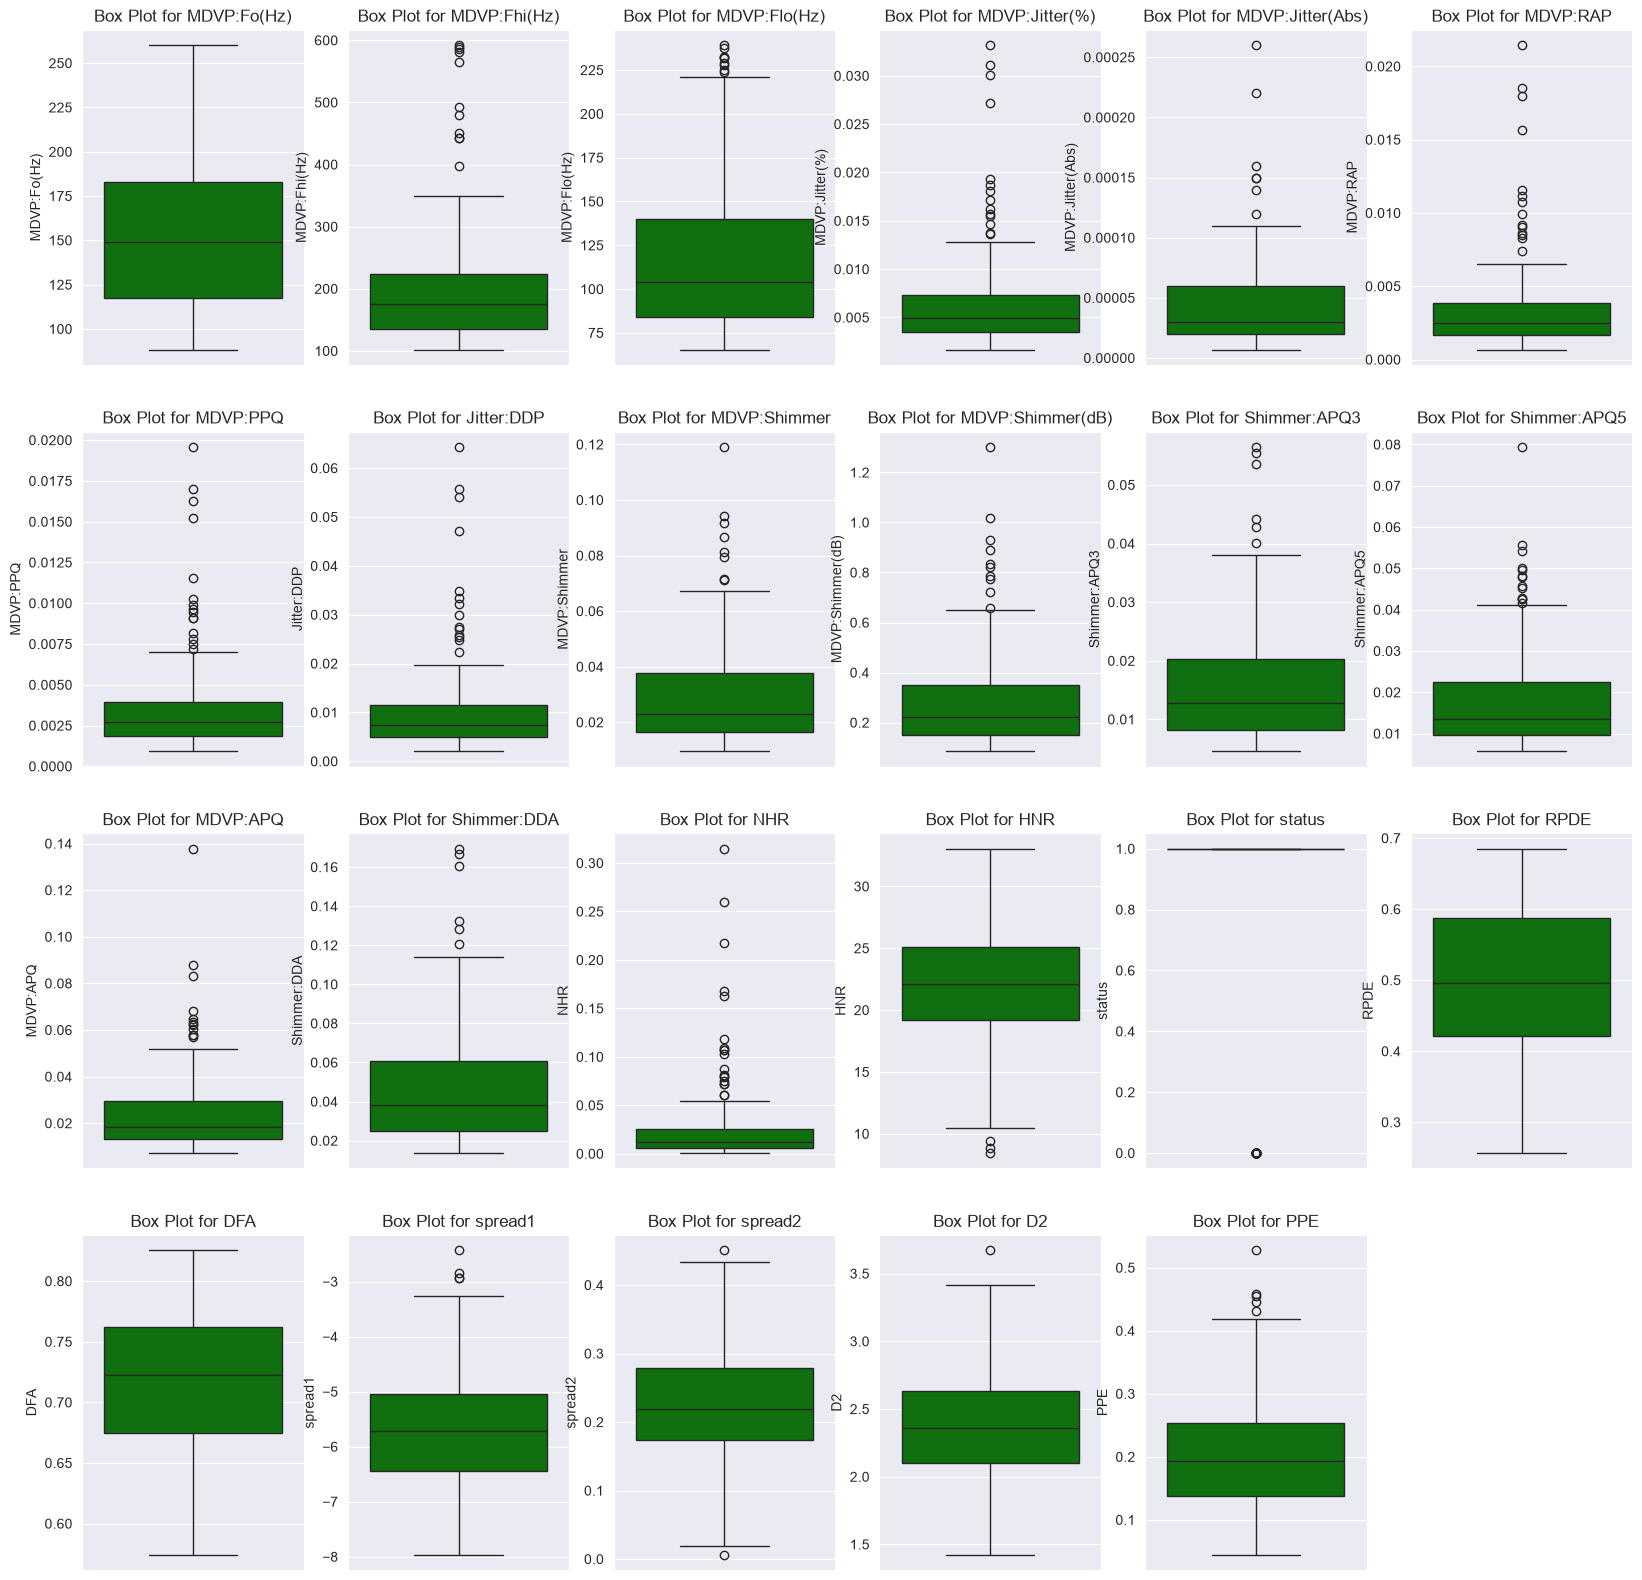

In [52]:
plt.figure(figsize=(20,20))
for number , column in enumerate(data.columns , 1)  :
    plt.subplot(4,6,number)
    sns.boxplot(data[column].dropna() , color="green")
    plt.title(f"Box Plot for {column}")
plt.savefig("../images/boxplot", dpi = 300,  bbox_inches="tight")
plt.show()

# Create box plots for all numerical features to detect outliers


In [53]:
x = data.drop(["status"], axis = 1)
y = data["status"]
print(f"x.shape : {x.shape}  y.shape : {y.shape}")

#splitting to data to x y

x.shape : (195, 22)  y.shape : (195,)


In [54]:
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size = 0.2, random_state = 42 , stratify=y)

# Check the class distribution in the 'status' column

In [55]:
pipline_knn = Pipeline([
    ("randomover" , RandomOverSampler(random_state=42)),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())

])

pipline_svc = Pipeline([
    ("randomover" , RandomOverSampler(random_state=42)),
    ("scaler", StandardScaler()),
    ("svc", SVC( ))

])

pipline_nb = Pipeline([
    ("randomover" , RandomOverSampler(random_state=42)),
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())

])


# Create machine learning pipelines

In [56]:
param_knn = {
    "knn__n_neighbors": [2,3,4,5, 7,9,10],

}
grid_knn = GridSearchCV(pipline_knn, param_knn , cv = 5)
grid_knn.fit(x_train, y_train)

param_svc = {
    "svc__kernel" : [ "rbf" ,"linear" ],
    "svc__C": [0.1,1,10]

}
grid_svc = GridSearchCV(pipline_svc, param_svc , cv = 5)
grid_svc.fit(x_train, y_train)
pipline_nb.fit(x_train, y_train)

print(grid_knn.best_params_)
print(grid_knn.best_score_)
print()
print(grid_svc.best_params_)
print(grid_svc.best_score_)

# Perform hyperparameter tuning using GridSearchCV

{'knn__n_neighbors': 5}
0.878225806451613

{'svc__C': 10, 'svc__kernel': 'rbf'}
0.9358870967741936


In [57]:
cross_knn = cross_val_score(
    pipline_knn,
    x_train,
    y_train,
    cv = 5
)

cross_svc = cross_val_score(
     pipline_svc,
    x_train,
    y_train,
    cv = 5
)

cross_nb = cross_val_score(
    pipline_nb,
    x_train,
    y_train,
    cv = 5)

print(f"""
cross_knn : {cross_knn}
knn_mean : {cross_knn.mean():.3f} ± knn_std : {cross_knn.std()*100:.2f} %

cross_svc : {cross_svc}
svc_mean : {cross_svc.mean():.3f} ± svc_std  : {cross_svc.std()*100:.2f} %

cross_nb : {cross_nb}
nb_mean : {cross_nb.mean():.3f} ± nb_std  : {cross_nb.std()*100:.2f} %
""")

# Evaluate models using Cross-Validation


cross_knn : [0.875      0.90322581 0.87096774 0.87096774 0.87096774]
knn_mean : 0.878 ± knn_std : 1.26 %

cross_svc : [0.8125     0.93548387 0.77419355 0.83870968 0.87096774]
svc_mean : 0.846 ± svc_std  : 5.47 %

cross_nb : [0.75       0.80645161 0.67741935 0.5483871  0.67741935]
nb_mean : 0.692 ± nb_std  : 8.66 %



In [58]:
best_svc = grid_svc.best_estimator_

best_knn = grid_knn.best_estimator_


In [59]:
y_pred_knn = best_knn.predict(x_test)
x_train_knn = best_knn.predict(x_train)

acc_knn = accuracy_score(y_test , y_pred_knn)
acc_knn_train = accuracy_score(x_train_knn , y_train)


gap = acc_knn_train - acc_knn

if gap <= 0.1:
    print("No significant overfitting.")
else:
    print(f"Possible overfitting (gap = {gap:.3f})")

recall_knn = recall_score(y_test , y_pred_knn)
precision_score_knn = precision_score(y_test , y_pred_knn)
f1_knn = f1_score(y_test , y_pred_knn)
confusion_matrix_knn = confusion_matrix(y_test,y_pred_knn)


# Evaluate model performance and check for overfitting

No significant overfitting.


In [60]:
print(f"Accuracy in knn : {acc_knn:.3f} \n Precision in knn : {precision_score_knn:.3f}  \n Recall in knn :  {recall_knn:.3f} \n f1 in knn : {f1_knn:.3f}  \n Confusion matrix in knn : \n {confusion_matrix_knn} ")


Accuracy in knn : 0.872 
 Precision in knn : 1.000  
 Recall in knn :  0.828 
 f1 in knn : 0.906  
 Confusion matrix in knn : 
 [[10  0]
 [ 5 24]] 


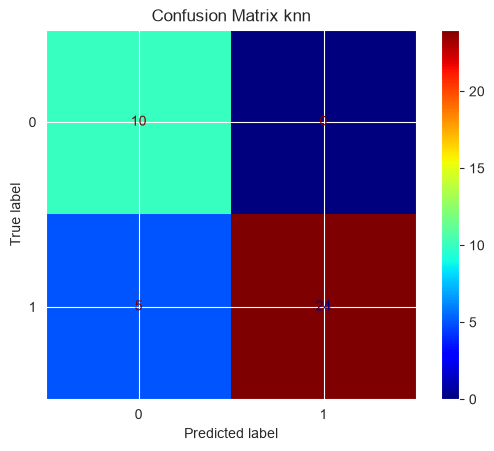

In [61]:
ConfusionMatrixDisplay.from_predictions( y_test, y_pred_knn , cmap='jet')
plt.title('Confusion Matrix knn')
plt.savefig("../images/confusion_matrix_knn.png")

In [62]:
y_pred_svc = best_svc.predict(x_test)
x_train_svc = best_svc.predict(x_train)


acc_svc = accuracy_score( y_test , y_pred_svc)
acc_svc_train = accuracy_score(x_train_svc , y_train)

gap_svc =acc_svc_train - acc_svc
if gap_svc <= 0.1:
    print("No significant overfitting.")
else :
    print(f"Possible overfitting (gap = {gap_svc:.3f})")


precision_score_svc = precision_score( y_test , y_pred_svc)
recall_svc = recall_score( y_test , y_pred_svc )
f1_svc = f1_score( y_test , y_pred_svc )

confusion_matrix_svc = confusion_matrix(y_test,y_pred_svc)

# Evaluate model performance and check for overfitting

No significant overfitting.


In [63]:
print(f"Accuracy in svc : {acc_svc:.3f} \n Precision in svc : {precision_score_svc:.3f}  \n Recall in svc :  {recall_svc:.3f} \n f1 in svc {f1_svc:.3f} \n Confusion matrix in svc : \n {confusion_matrix_svc} ")


Accuracy in svc : 0.897 
 Precision in svc : 0.931  
 Recall in svc :  0.931 
 f1 in svc 0.931 
 Confusion matrix in svc : 
 [[ 8  2]
 [ 2 27]] 


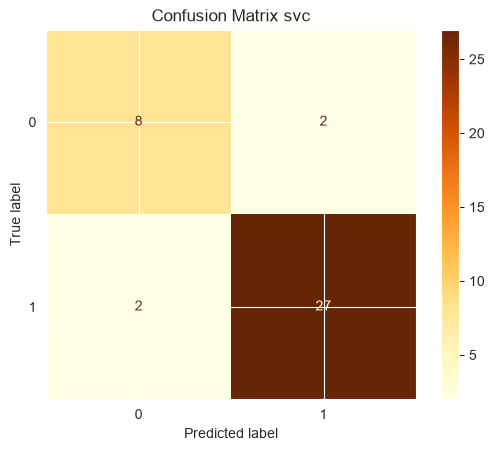

In [64]:
ConfusionMatrixDisplay.from_predictions( y_test, y_pred_svc , cmap='YlOrBr')
plt.title('Confusion Matrix svc')
plt.savefig("../images/confusion_matrix_svc.png")
plt.show()

In [65]:
y_pred_nb = pipline_nb.predict(x_test)
x_train_nb = pipline_nb.predict(x_train)


acc_nb = accuracy_score( y_test,y_pred_nb)
acc_nb_train = accuracy_score(x_train_nb , y_train)

gap_nb = acc_nb - acc_nb_train
if gap_nb <= 0.1:
    print("No significant overfitting.")
else:
    print(f"Possible overfitting (gap = {gap_nb:.3f})")



precision_score_nb = precision_score( y_test , y_pred_nb)

recall_nb = recall_score(y_test , y_pred_nb)
f1_nb = f1_score( y_test , y_pred_nb )
confusion_matrix_nb = confusion_matrix(y_test,y_pred_nb)

# Evaluate model performance and check for overfitting

No significant overfitting.


In [66]:
print(f"Accuracy in Naive_Bayes : {acc_nb:.3f} \n Precision in Naive_Bayes : {precision_score_nb:.3f}  \n Recall in Naive_Bayes :  {recall_nb:.3f} \n f1 in nb : {f1_nb :.3f} \n Confusion matrix in Naive_Bayes :\n {confusion_matrix_nb} ")

Accuracy in Naive_Bayes : 0.641 
 Precision in Naive_Bayes : 0.941  
 Recall in Naive_Bayes :  0.552 
 f1 in nb : 0.696 
 Confusion matrix in Naive_Bayes :
 [[ 9  1]
 [13 16]] 


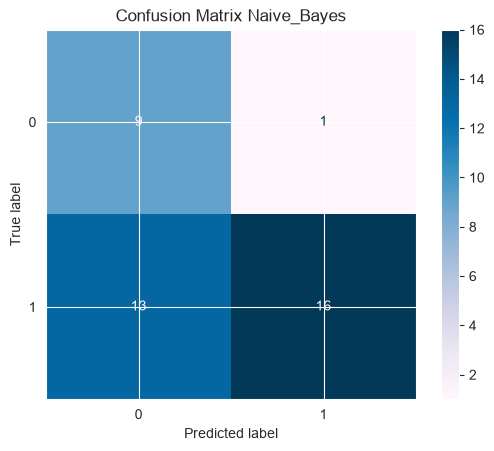

In [67]:
ConfusionMatrixDisplay.from_predictions(y_test , y_pred_nb , cmap='PuBu')
plt.title('Confusion Matrix Naive_Bayes')
plt.savefig("../images/confusion_matrix_nb.png")
plt.show()

         Model  Accuracy  Precision  Recall     F1
2          SVC     0.897      0.931   0.931  0.931
0  Naive_Bayes     0.641      0.941   0.552  0.696
1          KNN     0.872      1.000   0.828  0.906


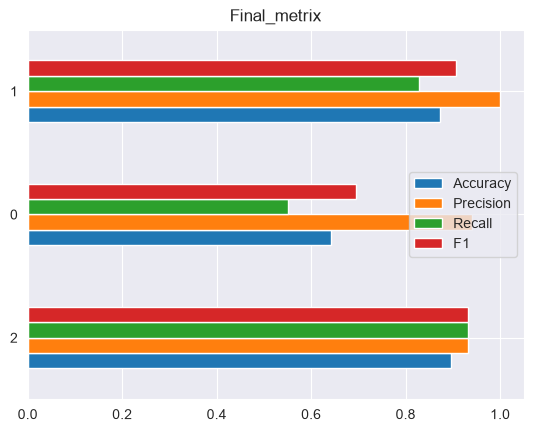

In [68]:
models = pd.DataFrame({
    "Model": ["Naive_Bayes", "KNN", "SVC" ],
    "Accuracy": [acc_nb, acc_knn, acc_svc],
    "Precision": [precision_score_nb, precision_score_knn, precision_score_svc],
    "Recall": [recall_nb, recall_knn, recall_svc],
    "F1": [f1_nb, f1_knn, f1_svc]

})
result = models.sort_values( by="Model", ascending=False )
result =  result.round (3)
print(result)
result.plot(kind="barh" )
plt.title("Final_metrix")
plt.savefig("../images/final_metrix.png")
plt.show()

# Compare model performance

In [69]:
joblib.dump(best_knn, "../models/parkinsons_knn_model.joblib")
joblib.dump(best_svc, "../models/parkinsons_svc_model.joblib")
joblib.dump(pipline_nb, "../models/parkinsons_nb_model.joblib")

# Load the saved model


['../models/parkinsons_nb_model.joblib']